In [26]:
!pip install jax
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import jax
import jax.numpy as jnp
from scipy.stats import weibull_min
import kagglehub
import shutil

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


In [28]:
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

# os.makedirs('data/raw/cmapss', exist_ok=True)
# os.makedirs('figures', exist_ok=True)

src = os.path.join(path, "CMaps")
dst = '../data/raw'

for f in os.listdir(src):
    if f.endswith('train_FD001.txt'):
        shutil.copy(os.path.join(src, f), dst)

In [29]:
cols = (
    ['unit', 'cycle', 'set1', 'set2', 'set3'] +
    [f's{i}' for i in range(1, 22)]
)

df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=cols)
df.head()

,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [30]:
t = df.groupby('unit')['cycle'].max().values

t.mean(), np.median(t), t.min(), t.max()

(np.float64(206.31), np.float64(199.0), np.int64(128), np.int64(362))

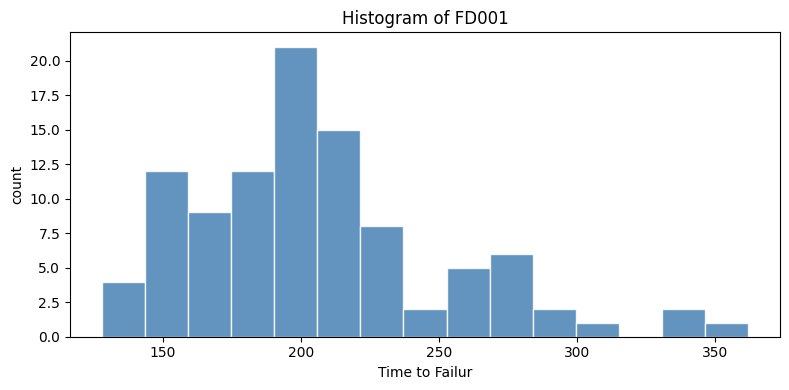

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(t, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Histogram of FD001')
ax.set_xlabel('Time to Failur')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [32]:
x = jnp.array(t, dtype=jnp.float32)

def nll(p, x):
    a, b = p[0], p[1]
    k = jnp.exp(a)
    lam = jnp.exp(b)
    n = x.shape[0]

    ll = (
        n * jnp.log(k)
        - n * k * jnp.log(lam)
        + (k - 1) * jnp.sum(jnp.log(x))
        - jnp.sum((x / lam) ** k)
    )
    return -ll

In [33]:
g = jax.grad(nll, argnums=0)

@jax.jit
def step(p, x, lr):
    return p - lr * g(p, x)

In [34]:
import tqdm

p = jnp.array([0.0, jnp.log(jnp.mean(x))], dtype=jnp.float32)
lr = 0.001

for i in tqdm.tqdm(range(5000)):
    p = step(p, x, lr)
    if i % 500 == 0:
        print(float(nll(p, x)))

100%|██████████| 5000/5000 [00:00<00:00, 37075.61it/s]

623.90087890625
530.7491455078125
530.7491455078125
530.7491455078125
530.7491455078125
530.7491455078125
530.7491455078125
530.7491455078125
530.7491455078125
530.7491455078125


In [35]:
k = float(jnp.exp(p[0]))
lam = float(jnp.exp(p[1]))

k, lam

(4.408709526062012, 225.0255584716797)

In [36]:
from scipy.stats import weibull_min

c, _, s = weibull_min.fit(t, floc=0)
c, s

(np.float64(4.408715194021367), np.float64(225.0258723462941))

In [37]:
print('k =', k)
print('k > 1 so increasing failure rate')

k = 4.408709526062012
k > 1 so increasing failure rate


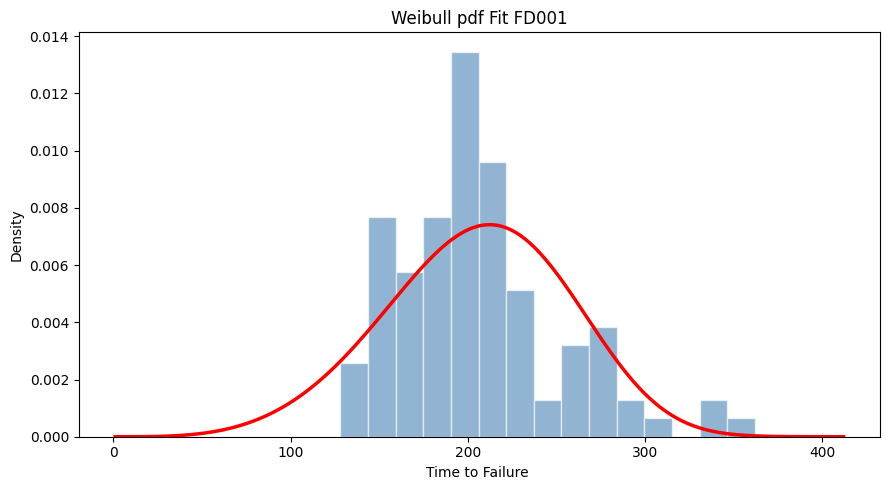

In [38]:
t_range = np.linspace(1, t.max() + 50, 500)
pdf = weibull_min.pdf(t_range, c=k, scale=lam)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(t, bins=15, density=True, color='steelblue', edgecolor='white', alpha=0.6)
ax.plot(t_range, pdf, 'r-', linewidth=2.5)
ax.set_title('Weibull pdf Fit FD001')
ax.set_xlabel('Time to Failure ')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

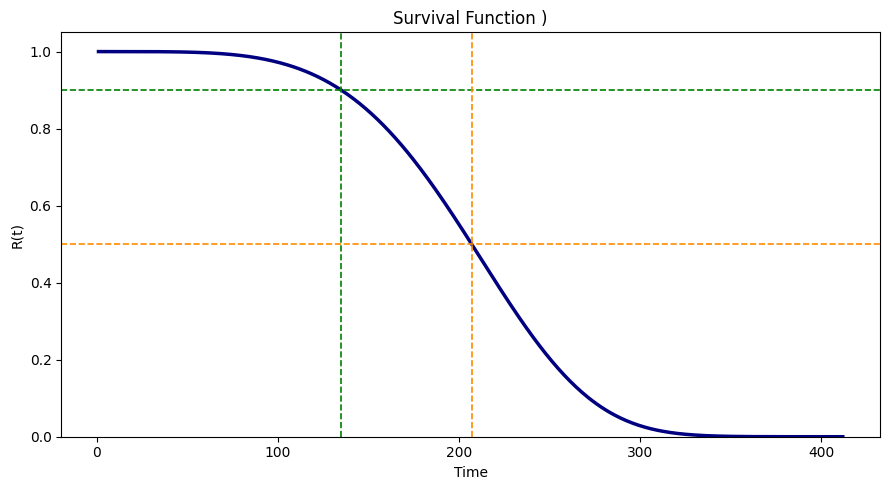

In [39]:
surv = 1 - weibull_min.cdf(t_range, c=k, scale=lam)
t90 = float(weibull_min.ppf(0.10, c=k, scale=lam))
t50 = float(weibull_min.ppf(0.50, c=k, scale=lam))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_range, surv, 'navy', linewidth=2.5)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1.2)
ax.axvline(t90, color='green', linestyle='--', linewidth=1.2)
ax.axhline(0.5, color='darkorange', linestyle='--', linewidth=1.2)
ax.axvline(t50, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_title('Survival Function )')
ax.set_xlabel('Time')
ax.set_ylabel('R(t)')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [40]:
t90, t50

(135.06785028298572, 207.07481563733094)